# Практическое задание 1. Обучение полносвязной нейронной сети

Вопросы по работе: **@aloschilov**.

Основная часть: **20 баллов**. Бонусные задания и их баллы указаны в разделе 4.

Это notebook с заданиями: заполните места `YOUR CODE HERE`. До заполнения они намеренно останавливаются с `NotImplementedError`.

In [7]:
import numpy as np
import torch

from glob import glob
from collections import OrderedDict
from matplotlib import pyplot as plt

from torch import nn
from torch.autograd import Function
from torch.autograd import gradcheck
from torch.optim import Optimizer, Adam
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets
from torchvision import transforms

# Для воспроизводимых численных проверок явно используйте CPU и float64.
# Основное обучение: float32; приоритет MPS -> CUDA -> CPU.
device = torch.device(
    "mps" if torch.backends.mps.is_built() and torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available() else "cpu"
)
print("Устройство обучения:", device)

Устройство обучения: cuda


## 1. Загрузка данных (0 баллов)

Если вам требуется работать с каким-нибудь набором данных (dataset), то, прежде всего, проверьте, нет ли его среди встроенных наборов данных https://pytorch.org/vision/stable/datasets.html.

В текущем домашнем задании мы будем работать с набором данных FashionMNIST. Он присутствует в списке встроенных наборов данных, однако мы воспользуемся реализацией только для удобного и быстрого способа скачать наборы данных. Ниже предлагается реализовать собственный класс для считывания, обработки и упаковки данных.

In [8]:
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True
)

Воспользуемся функцией загрузки данных из репозитория наборов данных.

In [9]:
! ls data/FashionMNIST/raw

t10k-images-idx3-ubyte	   train-images-idx3-ubyte
t10k-images-idx3-ubyte.gz  train-images-idx3-ubyte.gz
t10k-labels-idx1-ubyte	   train-labels-idx1-ubyte
t10k-labels-idx1-ubyte.gz  train-labels-idx1-ubyte.gz


In [10]:
#https://github.com/zalandoresearch/fashion-mnist/blob/master/utils/mnist_reader.py

def load_mnist(path, kind='train'):
    import os
    import gzip
    import numpy as np

    """Load MNIST data from `path`"""
    labels_path = os.path.join(path,
                               '%s-labels-idx1-ubyte.gz'
                               % kind)
    images_path = os.path.join(path,
                               '%s-images-idx3-ubyte.gz'
                               % kind)

    with gzip.open(labels_path, 'rb') as lbpath:
        labels = np.frombuffer(lbpath.read(), dtype=np.uint8,
                               offset=8)

    with gzip.open(images_path, 'rb') as imgpath:
        images = np.frombuffer(imgpath.read(), dtype=np.uint8,
                               offset=16).reshape(len(labels), 784)

    return images, labels

Для работы с данными PyTorch предоставляет `Dataset` и `DataLoader` из `torch.utils.data`.

Собственный набор данных реализуют как наследника `Dataset`: метод `__len__` возвращает число примеров, а `__getitem__` возвращает пример по индексу.

`DataLoader` использует этот набор данных, объединяет примеры в батчи и при `num_workers > 0` может загружать их в отдельных процессах. Наследоваться от `DataLoader` для этой работы не требуется.

Реализуем класс для FashionMNIST.

Элементами датасета должны являться пары `(np.ndarray, int)` до применения преобразований, массив имеет размерность `(28, 28)`, тип элемента `np.float32`.

In [11]:
import os

class FashionMnist(Dataset):
    def __init__(self, path, train=True, image_transform=None,
                 label_transform=None):
        if train:
            images, labels = load_mnist(os.path.join(path,"raw"))
        else:
            images, labels = load_mnist(os.path.join(path,"raw"), kind="t10k")

        self.images = images.reshape(-1, 28, 28).astype(np.float32)
        self.labels = labels.astype(np.int64)
        self.image_transform = image_transform
        self.label_transform = label_transform

    def __len__(self,):
        return len(self.labels)

    def __getitem__(self, idx):
        img, label = self.images[idx], int(self.labels[idx])
        if self.image_transform is not None:
            img = self.image_transform(img)
        if self.label_transform is not None:
            label = self.label_transform(label)
        return img, label


In [12]:
test_dataset = FashionMnist("data/FashionMNIST", train=False)
train_dataset = FashionMnist("data/FashionMNIST")

Визуализируйте случайные элементы набора данных.

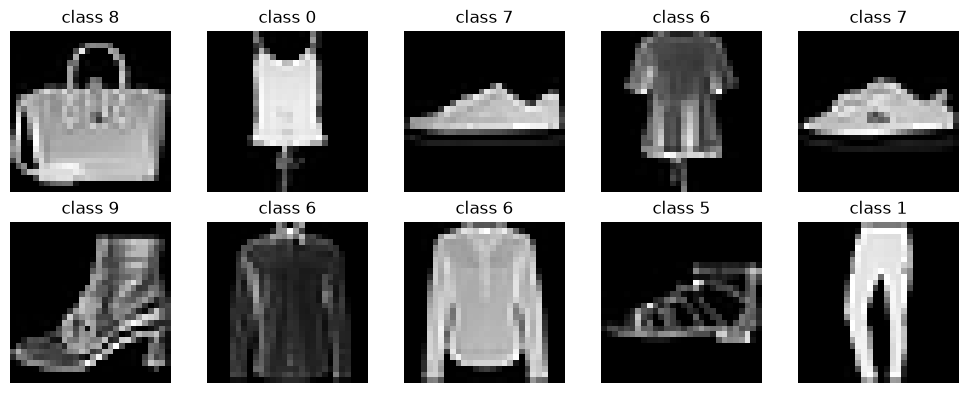

In [13]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, idx in zip(axes.ravel(), np.random.choice(len(train_dataset), 10, replace=False)):
    image, label = train_dataset[idx]
    ax.imshow(image, cmap='gray')
    ax.set_title(f'class {label}')
    ax.axis('off')
plt.tight_layout()


Наш `FashionMnist` принимает отдельные преобразования изображения и метки через `image_transform` и `label_transform`.

Реализуйте их применение в `FashionMnist`. Ниже дан простой преобразователь: он сохраняет dtype исходного массива и не нормирует значения пикселей. Для изображения подготовьте `np.float32`, для индекса класса используйте целое число. После преобразования метка должна иметь dtype `torch.int64`.

Это не полная копия `torchvision.transforms.ToTensor`: у библиотечного преобразования есть дополнительные правила обработки изображений.

In [14]:
class ToTensor:
    """Преобразует массив или целую метку в тензор без нормировки."""

    def __call__(self, sample):
        if isinstance(sample, (int, np.integer)):
            return torch.tensor(int(sample), dtype=torch.int64)
        return torch.as_tensor(sample)

In [15]:
transform = ToTensor()

test_dataset = FashionMnist("data/FashionMNIST",
                            train=False,
                            image_transform=transform,
                            label_transform=transform
                            )
train_dataset = FashionMnist("data/FashionMNIST",
                             image_transform=transform,
                             label_transform=transform
                             )

In [16]:
print(f"The type of the data is {type(test_dataset[0][0])}")

The type of the data is <class 'torch.Tensor'>


Элементы набора данных объединяются в батчи. Если стандартное объединение подходит для структуры примера, дополнительную функцию в `DataLoader` передавать не нужно.

In [17]:
test_dataloader = DataLoader(test_dataset, batch_size=15, num_workers=0, shuffle=True)
batch = next(iter(test_dataloader))

In [18]:
print(f"The length of the batch is {len(batch)}")
print(f"The shape of the batch[0] is {batch[0].shape}")

The length of the batch is 2
The shape of the batch[0] is torch.Size([15, 28, 28])


Однако, если наша структура данных не позволяет нам использовать объединение по умолчанию, то можно написать собственную функцию, которая будет пакетировать данные.

Реализуйте функцию, преобразующую последовательность элементов массива в пакет (batch).

In [19]:
def collate(batch):
    imgs, labels = zip(*batch)
    return torch.stack(list(imgs)), torch.stack(list(labels))

Убедитесь, что все работает корректно.

In [20]:
test_dataloader = DataLoader(test_dataset, batch_size=128, num_workers=0,
                             shuffle=True, collate_fn=collate)
train_dataloader = DataLoader(train_dataset, batch_size=128, num_workers=0,
                              shuffle=True, collate_fn=collate)
batch = next(iter(test_dataloader))

In [21]:
print(f"The length of the batch is {len(batch)}")
print(f"The shape of the batch[0] is {batch[0].shape}")

The length of the batch is 2
The shape of the batch[0] is torch.Size([128, 28, 28])


## 2. Реализация модулей нейронной сети (15 баллов)

В этом разделе мы полностью реализуем модули для полносвязной сети.

Для начала нам понадобится реализовать прямой и обратный проход через слои.

Наши слои будут соответствовать следующему интерфейсу (на примере "тождественного" слоя):

Сначала, мы реализуем функцию и её градиент.

In [22]:
class IdentityFunction(Function):
    """
    We can implement our own custom autograd Functions by subclassing
    torch.autograd.Function and implementing the forward and backward passes
    which operate on Tensors.
    """
    @staticmethod
    def forward(ctx, input):
        """
        In the forward pass we receive a Tensor containing the input and return
        a Tensor containing the output. ctx is a context object that can be used
        to stash information for backward computation. You can cache arbitrary
        objects for use in the backward pass using the ctx.save_for_backward method.
        """
        return input

    @staticmethod
    def backward(ctx, grad_output):
        """
        In the backward pass we receive a Tensor containing the gradient of the loss
        with respect to the output, and we need to compute the gradient of the loss
        with respect to the input.
        """
        return grad_output

Разработанную функцию обернем классом `IdentityLayer`, все слои в `PyTorch` должны быть наследниками базового класса `nn.Module()`


In [23]:
class IdentityLayer(nn.Module):
    def __init__(self):
        # An identity layer does nothing
        super().__init__()
        self.identity = IdentityFunction.apply

    def forward(self, inp):
        # An identity layer just returns whatever it gets as input.
        return self.identity(inp)


### 2.1 Функция активации ReLU (1 балл)
Для начала реализуем функцию активации, слой нелинейности `ReLU(x) = max(x, 0)`. Параметров у слоя нет. Метод `forward` должен вернуть результат поэлементного применения `ReLU` к входному массиву, метод `backward` - градиент функции потерь по входу слоя. В нуле обычная производная не существует; для обратного прохода выберем значение 0, как в PyTorch.

Для выпуклой функции ReLU субдифференциал в нуле равен $[0,1]$: любое число из этого интервала является допустимым субградиентом. Здесь фиксируем один выбор, а не утверждаем существование обычной производной. Центральная конечная разность в нуле даёт $1/2$, поэтому несовпадение с выбранным значением 0 само по себе не означает ошибку backward. Это пояснение, не дополнительное задание.

 Обратите внимание, что при обратном проходе могут понадобиться величины, посчитанные во время прямого прохода, поэтому их стоит сохранить в `ctx`.

In [24]:
class ReLUFunction(Function):
    @staticmethod
    def forward(ctx, input):
        ctx.save_for_backward(input)
        return input.clamp_min(0)

    @staticmethod
    def backward(ctx, grad_output):
        (input,) = ctx.saved_tensors
        return grad_output * (input > 0).to(grad_output.dtype)


In [25]:
class ReLU(nn.Module):
    def __init__(self):
        super().__init__()
        self.activation = ReLUFunction.apply


    def forward(self, input):
        return self.activation(input)

После реализации проверьте градиенты с помощью `gradcheck`. Для численной проверки используйте CPU, `torch.float64` и входы с `requires_grad=True`. Проверки выполняйте вдали от точек излома; для ReLU не берите нулевые и слишком близкие к нулю входы. При сравнении со встроенным модулем используйте одинаковые dtype и device.

In [26]:
relu = ReLU().cpu().double()
x = (torch.randn(4, 5, dtype=torch.float64) + 0.5).requires_grad_()

assert gradcheck(relu, x)

In [27]:
x = torch.randn(4, 5, dtype=torch.float64)
torch_relu, our_relu = nn.ReLU(), ReLU()

assert torch.norm(torch_relu(x) - our_relu(x)) < 1e-5

### 2.2 Линейный слой (linear, fully-connected) (3 балла)
Далее реализуем полносвязный слой без нелинейности. У слоя два набора параметров: матрица весов (weights) и вектор смещения (bias).

In [28]:
class LinearFunction(Function):
    @staticmethod
    def forward(ctx, inp, weight, bias):
        ctx.save_for_backward(inp, weight)
        return inp.matmul(weight.t()) + bias
    @staticmethod
    def backward(ctx, grad_output):
        inp, weight = ctx.saved_tensors
        grad_input = grad_output.matmul(weight)
        grad_weight = grad_output.t().matmul(inp)
        grad_bias = grad_output.sum(dim=0)
        return grad_input, grad_weight, grad_bias

In [29]:
class Linear(nn.Module):
    def __init__(self, input_units, output_units):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(output_units, input_units) * 0.01)
        self.bias = nn.Parameter(torch.zeros(output_units))
        self.linear = LinearFunction.apply

    def forward(self,inp):
        return self.linear(inp, self.weight, self.bias)


Проверим градиенты и сравним работу нашего модуля с `torch.nn.Linear` при одинаковых весах и входах.

Проверка градиента:

In [30]:
linear = Linear(3, 2).cpu().double()
inp = torch.randn(4, 3, dtype=torch.float64, requires_grad=True)
assert gradcheck(linear, (inp,))


Сравнение с `PyTorch`.

In [31]:
torch.manual_seed(0)
weight = torch.randn(2, 3)
bias = torch.randn(2)
torch_linear, our_linear = nn.Linear(3, 2), Linear(3, 2)

state_dict = OrderedDict([("weight", weight), ("bias", bias)])
torch_linear.load_state_dict(state_dict)
our_linear.load_state_dict(state_dict)

x = torch.randn(4, 3)
assert torch.allclose(torch_linear(x), our_linear(x), atol=1e-6)


### 2.3 LogSoftmax (Log + Softmax) (4 балла)

Для многоклассовой классификации `softmax` преобразует логиты $x$ в вероятности классов:

$$
\hat y_i=\frac{\exp(x_i)}{\sum_{j=1}^{K}\exp(x_j)},\qquad i=1,\ldots,K.
$$

Здесь $K$ обозначает число классов. Для одного объекта с one-hot меткой $y$ кросс-энтропия равна отрицательному логарифму правдоподобия:

$$
\ell(y,\hat y)=-\sum_{i=1}^{K}y_i\log\hat y_i.
$$

Если $c$ обозначает индекс истинного класса, ту же потерю можно записать короче:

$$
\ell(c,\hat y)=-\log\hat y_c.
$$

Реализуйте слой `LogSoftmax` без параметров. Метод `forward` вычисляет логарифмы вероятностей, а `backward` вычисляет градиент потерь по входу из входящего `grad_output`.

Явный якобиан для батча был бы трёхмерным тензором, но строить его не обязательно. Сохраняется допущение исходного задания: достаточно поддержать `grad_output`, у которого в каждой строке только один ненулевой элемент (не обязательно единица).

Для полного балла нужна реализация с **Log-Sum-Exp trick**.

In [32]:
class LogSoftmaxFunction(Function):
    @staticmethod
    def forward(ctx, inp):
        max_values = inp.max(dim=1, keepdim=True).values
        shifted = inp - max_values
        output = shifted - shifted.exp().sum(dim=1, keepdim=True).log()
        ctx.save_for_backward(output)
        return output

    @staticmethod
    def backward(ctx, grad_output):
        (log_probs,) = ctx.saved_tensors
        return grad_output - log_probs.exp() * grad_output.sum(dim=1, keepdim=True)


In [33]:
class LogSoftmax(nn.Module):
    def __init__(self):
        super().__init__()
        self.log_softmax = LogSoftmaxFunction.apply

    def forward(self, input):
        return self.log_softmax(input)


Проверка градиентов.

In [34]:
log_softmax = LogSoftmax().cpu().double()
x = torch.randn(4, 5, dtype=torch.float64, requires_grad=True)
assert gradcheck(log_softmax, (x,))
assert torch.allclose(log_softmax(x), torch.log_softmax(x, dim=1))


### 2.4 Dropout (2 балла)
Реализуйте слой Dropout. Здесь `p` означает вероятность зануления. Поведение в режимах `train()` и `eval()` должно соответствовать `torch.nn.Dropout`.

При численной проверке случайная маска должна оставаться одной и той же для всех вычислений сравниваемой функции. Иначе конечная разность измеряет также изменение маски и не проверяет производную.

In [35]:
class DropoutFunction(Function):
    @staticmethod
    def forward(ctx, inp, p):
        if not 0 <= p <= 1:
            raise ValueError('p must be in [0, 1]')
        if p == 1:
            mask = torch.zeros_like(inp)
        else:
            mask = (torch.rand_like(inp) > p).to(inp.dtype) / (1 - p)
        ctx.save_for_backward(mask)
        return inp * mask

    @staticmethod
    def backward(ctx, grad_output):
        (mask,) = ctx.saved_tensors
        return grad_output * mask, None


In [36]:
class Dropout(nn.Module):
    def __init__(self, p):
        super().__init__()
        if not 0 <= p <= 1:
            raise ValueError('p must be in [0, 1]')
        self.p = p

    def forward(self, input):
        return DropoutFunction.apply(input, self.p) if self.training else input


### 2.5 CrossEntropy (5 баллов)

При решении задачи многоклассовой классификации мы будем использовать в качестве функции потерь **кроссэнтропию, совместимую с `LogSoftmax` активацией**.

На вход поступают **логарифмы вероятностей** из вашего `LogSoftmax`, а не логиты. По этому интерфейсу функция соответствует `torch.nn.NLLLoss`, а не `torch.nn.CrossEntropyLoss`, которая сама включает LogSoftmax. Возвращайте среднюю потерю по батчу, как ожидает приведённый цикл обучения. Метки представляются индексами классов (`torch.int64`).

Реализуйте эту функцию потерь. В разделе 2.3 приведены полезные формулы.

In [37]:
class CrossEntropyFunction(Function):
    @staticmethod
    def forward(ctx, activations, target):
        if activations.ndim != 2 or target.ndim != 1:
            raise ValueError('Expected activations [batch, classes] and targets [batch]')
        if activations.shape[0] != target.shape[0]:
            raise ValueError('Batch sizes must match')
        ctx.save_for_backward(target)
        ctx.shape = activations.shape
        return -activations.gather(1, target[:, None]).mean()

    @staticmethod
    def backward(ctx, grad_output):
        (target,) = ctx.saved_tensors
        batch_size, num_classes = ctx.shape
        grad_activations = torch.zeros((batch_size, num_classes), device=target.device, dtype=grad_output.dtype)
        grad_activations[torch.arange(batch_size, device=target.device), target] = -grad_output / batch_size
        return grad_activations, None

class CrossEntropy(nn.Module):
    def __init__(self, ):
        super().__init__()
        self.loss = CrossEntropyFunction.apply

    def forward(self, activations, target):
        return self.loss(activations, target)


Проверка градиентов.

In [38]:
criterion_check = CrossEntropy().cpu().double()
log_probs = torch.log_softmax(torch.randn(4, 5, dtype=torch.float64), dim=1).requires_grad_()
targets = torch.tensor([0, 1, 3, 4], dtype=torch.int64)
assert gradcheck(criterion_check, (log_probs, targets))
assert torch.allclose(criterion_check(log_probs, targets), nn.NLLLoss()(log_probs, targets))


## 3. Сборка и обучение нейронной сети (5 баллов)

**В этой работе стандартный тестовый набор FashionMNIST (`train=False`, `test_dataloader`) используется как валидационная выборка для оценки loss и accuracy, наблюдения за обучением и сравнения моделей. Используйте его во всех экспериментах; отдельное разбиение создавать не требуется. Независимая тестовая оценка после выбора модели в эту работу не входит.**

Реализуйте из ваших блоков персептрон и обучите его, записав итоговую функцию потерь и accuracy на валидационной выборке. **(1 балл)**

Подсказка: вытягиваем картинку в вектор с помощью [nn.Flatten](https://pytorch.org/docs/stable/generated/torch.nn.Flatten.html)

In [39]:
class Network(nn.Module):
    def __init__(self, input_size=28*28, hidden_layers_size=32, num_layers=5,
                 num_classes=10):
        super().__init__()
        if num_layers < 1:
            raise ValueError('num_layers must be positive')
        layers = [nn.Flatten()]
        in_features = input_size
        for _ in range(num_layers - 1):
            layers.extend([Linear(in_features, hidden_layers_size), ReLU()])
            in_features = hidden_layers_size
        layers.extend([Linear(in_features, num_classes), LogSoftmax()])
        self.layers = nn.Sequential(*layers)

    def forward(self, inp):
        return self.layers(inp)
    def predict(self, inp):
        return self(inp).argmax(dim=1)


Ниже приведены функции, реализующие обучение нейронной сети. В данном задании их предлагается просто переиспользовать.

In [40]:
class EmptyContext:
    def __enter__(self):
        pass

    def __exit__(self, *args):
        pass

In [41]:
# accuracy metric for our classififcation
def accuracy(model_labels, labels):
  return torch.mean((model_labels == labels).float())

In [42]:
def perform_epoch(model, loader, criterion, optimizer=None, device=None):
    is_train = optimizer is not None
    model = model.to(device)
    model.train(is_train)
    total_loss = 0.0
    total_correct = 0
    total_n = 0
    with EmptyContext() if is_train else torch.no_grad():
        for batch_data, batch_labels in loader:
            batch_data = batch_data.to(device)
            batch_labels = batch_labels.to(device)
            if is_train:
                optimizer.zero_grad()
            model_labels = model(batch_data)
            new_loss = criterion(model_labels, batch_labels)
            model_prediction = model_labels.detach().argmax(dim=1)
            if is_train:
                new_loss.backward()
                optimizer.step()
            batch_n = batch_labels.shape[0]
            total_loss += new_loss.detach().item() * batch_n
            total_correct += (model_prediction == batch_labels).sum().item()
            total_n += batch_n
    if total_n == 0:
        raise ValueError("Набор данных не должен быть пустым")
    return total_loss / total_n, total_correct / total_n

Теперь обучим нашу нейронную сеть. В данном разделе будем использовать оптимизатор `Adam` с параметрами по умолчанию.

In [43]:
model = Network(hidden_layers_size=128, num_layers=3).to(device=device, dtype=torch.float32)
criterion = CrossEntropy()
optimizer = Adam(model.parameters())

In [44]:
for epoch in range(5):
    loss, acc = perform_epoch(model, train_dataloader, criterion,
                                optimizer=optimizer, device=device)
    print(f"Epoch - {epoch} : loss {loss}, accuracy {acc}")
    print(f"Current learning rate: {optimizer.param_groups[0]['lr']}")

Epoch - 0 : loss 0.507859305524826, accuracy 0.8161
Current learning rate: 0.001
Epoch - 1 : loss 0.38675887619654337, accuracy 0.8581833333333333
Current learning rate: 0.001
Epoch - 2 : loss 0.3543399208386739, accuracy 0.8702333333333333
Current learning rate: 0.001
Epoch - 3 : loss 0.3332185338020325, accuracy 0.8773333333333333
Current learning rate: 0.001
Epoch - 4 : loss 0.3147512196858724, accuracy 0.8839
Current learning rate: 0.001


In [45]:
print(f"Epoch - {epoch} : loss {loss}, accuracy {acc}")
print(f"Current learning rate: {optimizer.param_groups[0]['lr']}")

Epoch - 4 : loss 0.3147512196858724, accuracy 0.8839
Current learning rate: 0.001


Дальше **(4 балла)**:
- Проведите эксперименты с числом слоев.
- Постройте графики зависимости качества модели на обучающей и валидационной выборках от числа слоев. Для получения статистически значимых результатов повторите эксперименты несколько раз.
- Сделайте выводы.

Training Loop для выполнения этой части задания можно и нужно улучшать, в том числе, добавляя более продвинутое логгирование эксперимента.

depth=1, seed=11: train=0.8583, val=0.8400, loss=0.4586
depth=1, seed=22: train=0.8589, val=0.8399, loss=0.4581
depth=1, seed=33: train=0.8558, val=0.8399, loss=0.4633
depth=1, seed=44: train=0.8583, val=0.8388, loss=0.4605
depth=1, seed=55: train=0.8592, val=0.8405, loss=0.4590
depth=2, seed=11: train=0.9067, val=0.8796, loss=0.3427
depth=2, seed=22: train=0.8991, val=0.8714, loss=0.3554
depth=2, seed=33: train=0.9033, val=0.8772, loss=0.3448
depth=2, seed=44: train=0.8973, val=0.8712, loss=0.3598
depth=2, seed=55: train=0.9016, val=0.8751, loss=0.3543
depth=3, seed=11: train=0.9167, val=0.8854, loss=0.3178
depth=3, seed=22: train=0.9074, val=0.8778, loss=0.3401
depth=3, seed=33: train=0.9140, val=0.8818, loss=0.3340
depth=3, seed=44: train=0.9115, val=0.8794, loss=0.3350
depth=3, seed=55: train=0.9121, val=0.8816, loss=0.3309
depth=5, seed=11: train=0.9175, val=0.8867, loss=0.3218
depth=5, seed=22: train=0.9136, val=0.8783, loss=0.3545
depth=5, seed=33: train=0.9162, val=0.8839, loss

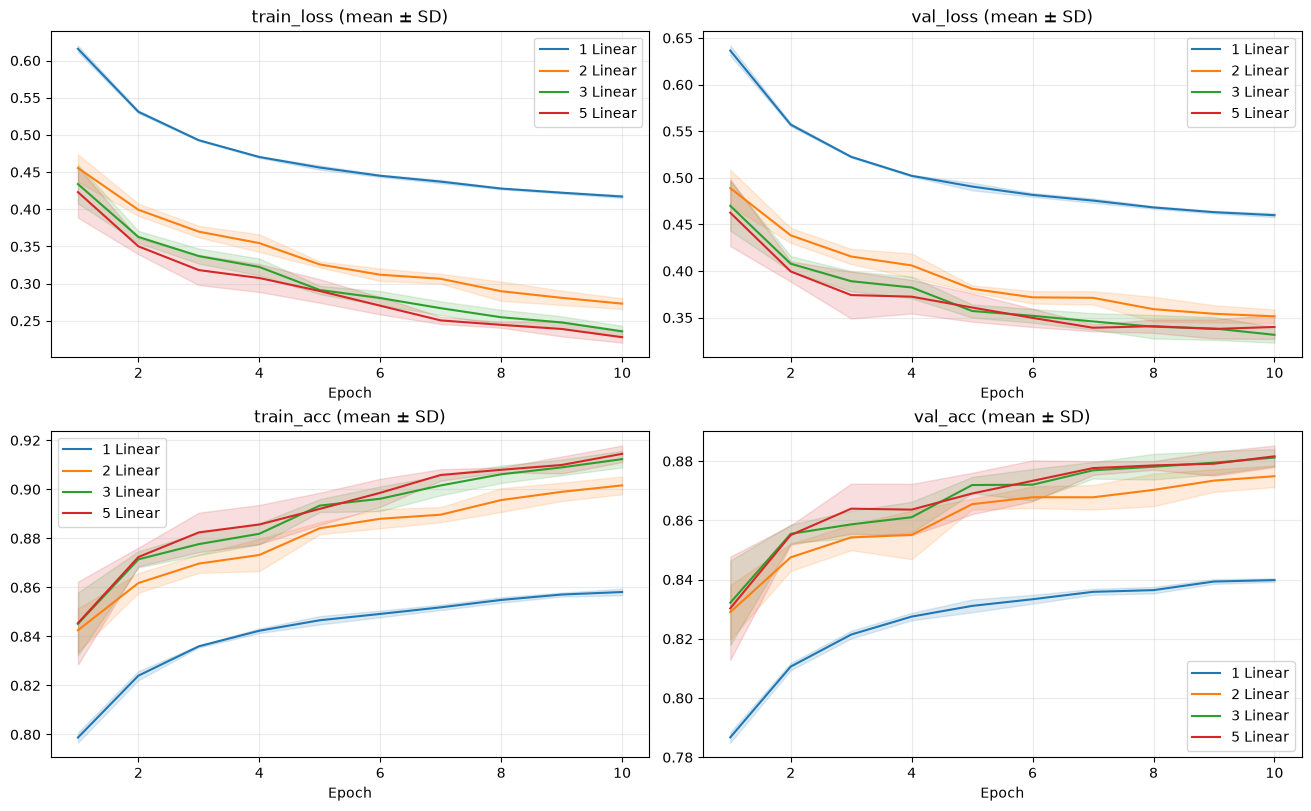

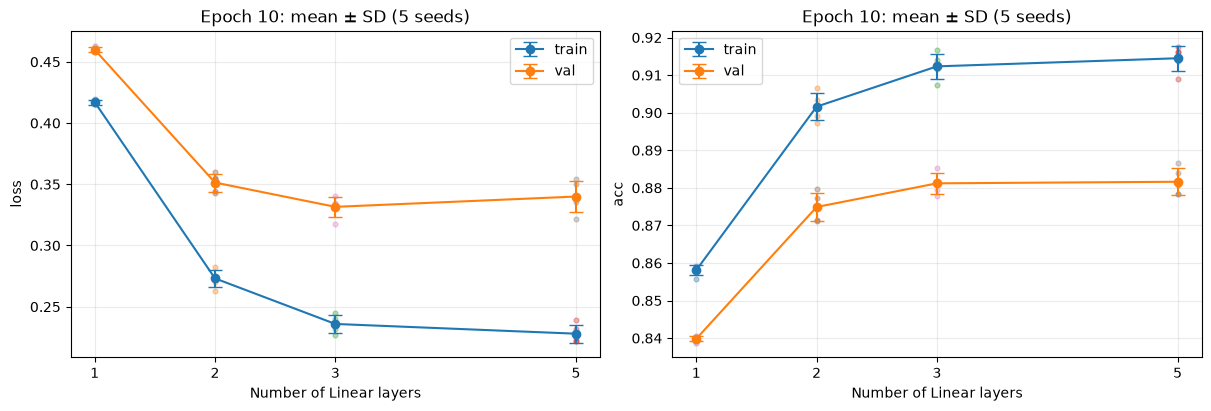

Depth | Parameters | Train accuracy | Validation accuracy | Validation loss
    1 |       7850 | 0.8581 ± 0.0013 | 0.8398 ± 0.0006 | 0.4599 ± 0.0021
    2 |     101770 | 0.9016 ± 0.0036 | 0.8749 ± 0.0037 | 0.3514 ± 0.0073
    3 |     118282 | 0.9123 ± 0.0034 | 0.8812 ± 0.0029 | 0.3316 ± 0.0084
    5 |     151306 | 0.9145 ± 0.0034 | 0.8816 ± 0.0036 | 0.3400 ± 0.0129
Лучшая средняя validation accuracy после 10 эпох: 5 Linear.


In [46]:
import json
from pathlib import Path

# depth — число Linear вместе с выходным слоем.
depths, seeds = [1, 2, 3, 5], [11, 22, 33, 44, 55]
experiment_epochs, batch_size, width = 10, 256, 128
torch.set_num_threads(4)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True
train_eval = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
val_eval = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

class DepthNetwork(nn.Module):
    def __init__(self, depth):
        super().__init__()
        self.net = Network(hidden_layers_size=width, num_layers=depth)
        layers = [m for m in self.net.modules() if isinstance(m, Linear)]
        for layer in layers[:-1]:
            nn.init.kaiming_normal_(layer.weight, nonlinearity="relu")
            nn.init.zeros_(layer.bias)
        nn.init.xavier_normal_(layers[-1].weight)
        nn.init.zeros_(layers[-1].bias)

    def forward(self, x):
        return self.net(x / 255.0)

history, parameter_counts = [], {}
for depth in depths:
    for seed in seeds:
        np.random.seed(seed)
        torch.manual_seed(seed)
        net = DepthNetwork(depth).to(device=device, dtype=torch.float32)
        parameter_counts[depth] = sum(p.numel() for p in net.parameters())
        loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                            generator=torch.Generator().manual_seed(seed))
        opt = Adam(net.parameters())
        for epoch in range(1, experiment_epochs + 1):
            perform_epoch(net, loader, CrossEntropy(), optimizer=opt, device=device)
            # Обе метрики — eval на одних и тех же весах после эпохи.
            tl, ta = perform_epoch(net, train_eval, CrossEntropy(), device=device)
            vl, va = perform_epoch(net, val_eval, CrossEntropy(), device=device)
            history.append(dict(depth=depth, seed=seed, epoch=epoch,
                                train_loss=tl, train_acc=ta, val_loss=vl, val_acc=va))
        print(f"depth={depth}, seed={seed}: train={ta:.4f}, val={va:.4f}, loss={vl:.4f}",
              flush=True)

artifact_dir = Path("depth_experiment")
artifact_dir.mkdir(exist_ok=True)
(artifact_dir / "results.json").write_text(json.dumps(
    dict(depths=depths, seeds=seeds, epochs=experiment_epochs,
         batch_size=batch_size, width=width, parameters=parameter_counts,
         device=str(device), torch_version=torch.__version__, history=history),
    indent=2), encoding="utf-8")

def runs(depth, metric):
    return np.array([[r[metric] for r in history
                      if r["depth"] == depth and r["seed"] == seed]
                     for seed in seeds])

fig, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)
for ax, metric in zip(axes.ravel(), ["train_loss", "val_loss", "train_acc", "val_acc"]):
    for depth in depths:
        data = runs(depth, metric)
        mean, sd = data.mean(0), data.std(0, ddof=1)
        epochs = np.arange(1, experiment_epochs + 1)
        line, = ax.plot(epochs, mean, label=f"{depth} Linear")
        ax.fill_between(epochs, mean - sd, mean + sd,
                        color=line.get_color(), alpha=0.15)
    ax.set(title=metric + " (mean ± SD)", xlabel="Epoch")
    ax.grid(alpha=0.25)
    ax.legend()
fig.savefig(artifact_dir / "learning_curves.png", dpi=160)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
for ax, metric in zip(axes, ["loss", "acc"]):
    for split in ["train", "val"]:
        data = np.array([runs(d, f"{split}_{metric}")[:, -1] for d in depths])
        ax.errorbar(depths, data.mean(1), yerr=data.std(1, ddof=1),
                    marker="o", capsize=5, label=split)
        for depth, samples in zip(depths, data):
            ax.scatter([depth] * len(seeds), samples, s=12, alpha=0.35)
    ax.set(xlabel="Number of Linear layers", ylabel=metric,
           title=f"Epoch {experiment_epochs}: mean ± SD ({len(seeds)} seeds)")
    ax.set_xticks(depths)
    ax.grid(alpha=0.25)
    ax.legend()
fig.savefig(artifact_dir / "depth_comparison.png", dpi=160)
plt.show()

print("Depth | Parameters | Train accuracy | Validation accuracy | Validation loss")
for depth in depths:
    stats = [runs(depth, m)[:, -1] for m in ["train_acc", "val_acc", "val_loss"]]
    print(f"{depth:5} | {parameter_counts[depth]:10} | " +
          " | ".join(f"{x.mean():.4f} ± {x.std(ddof=1):.4f}" for x in stats))
best = max(depths, key=lambda d: runs(d, "val_acc")[:, -1].mean())
print(f"Лучшая средняя validation accuracy после {experiment_epochs} эпох: {best} Linear.")


### Выводы по эксперименту с глубиной

При фиксированной ширине 128, Adam с параметрами по умолчанию и 10 эпохах средняя точность на валидации по пяти сидам составила: 1 слой — 83,98%, 2 — 87,49%, 3 — 88,12%, 5 — 88,16%. Добавление скрытых слоёв заметно улучшает результат относительно линейного классификатора.

Разница между 3 и 5 слоями составляет только 0,04 процентного пункта при стандартном отклонении 0,29 и 0,36 п.п. соответственно. Эти результаты не дают основания утверждать уверенное преимущество пятислойной сети. У трёхслойной сети ниже средний лосс на валидации (0,3316 против 0,3400) и меньше параметров (118282 против 151306), поэтому в рамках этого эксперимента она выглядит разумным компромиссом.

Разрыв точности между тренировкой и валидацией растёт примерно с 1,83 п.п. для линейной модели до 3,29 п.п. для пятислойной. Это согласуется с увеличением способности модели подстраиваться под обучающие данные. Выводы ограничены выбранными шириной, инициализацией и бюджетом эпох: глубина и число параметров здесь меняются одновременно. Полосы на графиках — выборочное стандартное отклонение между seed, не доверительный интервал.

## 4. Бонусная часть.

### 4.1 Реализация метода оптимизации (3 + 3 балла).
Реализуйте сами метод оптимизации  для рассмотренной выше архитектуры. Вы можете выбрать произвольный метод от градиентного спуска до современных вариантов. Продемонстрируйте правильную работу метода оптимизации, сравните его работу с Adam.

**Дополнительные баллы** вы получите, если метод будет уникален среди сдавших задание.

### COCOB-Backprop: оптимизация через ставки (лудомания)

Источник: Orabona & Tommasi, [NeurIPS 2017](https://arxiv.org/abs/1705.07795); [авторская PyTorch-реализация](https://github.com/bremen79/parameterfree/blob/main/parameterfree/cocob.py). Реализация ниже самостоятельная, формулы сверены с источником. Для каждой координаты храним сумму градиентов, сумму модулей, максимальный наблюдавшийся масштаб и неотрицательный выигрыш. Положение вычисляется относительно начальных весов. Метод не требует learning rate; alpha=100 и eps=1e-8 фиксированы до эксперимента. Отсутствие lr не означает отсутствия любых гиперпараметров.

Протокол: сеть 784–128–128–10 из собственных слоёв, He/Xavier, вход x/255, batch=256, 20 эпох и пять сидов (11,22,33,44,55). Начальные веса и порядок батчей совпадают между методами для каждого сида. Для Adam выбираем lr из [0.0003,0.001,0.003] по лоссу на валидации после 10 эпох на отдельном сиде 101; COCOB запускается с фиксированными настройками без подбора.

In [47]:
class COCOB(Optimizer):
    """COCOB-Backprop; coordinate-wise coin betting without a tuned lr.

    Orabona & Tommasi (NeurIPS 2017), alpha=100 as recommended.
    eps is the initial lower bound on the observed gradient scale.
    """
    def __init__(self, params, alpha=100., eps=1e-8):
        if not np.isfinite(alpha) or alpha <= 0 or not np.isfinite(eps) or eps <= 0:
            raise ValueError('alpha and eps must be finite and positive')
        super().__init__(params, dict(alpha=alpha, eps=eps))

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()
        for group in self.param_groups:
            for p in group['params']:
                if p.grad is None:
                    continue
                grad = p.grad
                if grad.is_sparse or p.is_complex():
                    raise RuntimeError('COCOB supports dense real parameters only')
                state = self.state[p]
                if not state:
                    state['initial'] = p.detach().clone()
                    state['gradient_sum'] = torch.zeros_like(p)
                    state['absolute_sum'] = torch.zeros_like(p)
                    state['scale'] = torch.full_like(p, group['eps'])
                    state['reward'] = torch.zeros_like(p)
                magnitude = grad.abs()
                state['scale'].copy_(torch.maximum(state['scale'], magnitude))
                state['gradient_sum'].add_(grad)
                state['absolute_sum'].add_(magnitude)
                state['reward'].sub_(grad * (p - state['initial'])).clamp_min_(0)
                scale = state['scale']
                budget = torch.maximum(state['absolute_sum'] + scale, group['alpha'] * scale)
                displacement = -(state['gradient_sum'] / scale) * ((state['reward'] + scale) / budget)
                p.copy_(state['initial'] + displacement)
        return loss

SotaOptimizer = COCOB


In [48]:
import copy

start = np.array([0.5, -0.7, 2.0])
point = start.copy()
total, absolute, reward = np.zeros(3), np.zeros(3), np.zeros(3)
scale = np.full(3, 1e-8)
p = nn.Parameter(torch.tensor(start, dtype=torch.float64))
optimizer_check = COCOB([p])
for g in [np.zeros(3), np.array([1., -2., 0.]), np.array([-3., 0.2, 0.]),
          np.array([0.1, 0.4, 0.]), np.array([0., -4., 0.])]:
    scale = np.maximum(scale, np.abs(g))
    total += g
    absolute += np.abs(g)
    reward = np.maximum(reward - g*(point-start), 0)
    point = start-total*(scale+reward)/(scale*np.maximum(absolute+scale, 100*scale))
    p.grad = torch.tensor(g)
    optimizer_check.step()
    np.testing.assert_allclose(p.detach().numpy(), point, rtol=1e-12, atol=1e-12)
    for key, expected in [('gradient_sum', total), ('absolute_sum', absolute),
                          ('reward', reward), ('scale', scale)]:
        np.testing.assert_allclose(optimizer_check.state[p][key].numpy(), expected, atol=1e-12)

q = nn.Parameter(p.detach().clone())
resumed = COCOB([q], alpha=7)
resumed.load_state_dict(copy.deepcopy(optimizer_check.state_dict()))
p.grad = torch.tensor([0.3, -0.2, 0.], dtype=p.dtype)
q.grad = p.grad.clone()
optimizer_check.step()
resumed.step()
torch.testing.assert_close(p, q, rtol=0, atol=0)
assert resumed.param_groups[0]['alpha'] == 100
before = p.detach().clone()
p.grad = None
optimizer_check.step()
torch.testing.assert_close(p, before, rtol=0, atol=0)

p = nn.Parameter(torch.tensor([2., -3.], dtype=torch.float64))
optimizer_check = COCOB([p])
for _ in range(1000):
    def closure():
        optimizer_check.zero_grad()
        objective = p.square().sum()/2
        objective.backward()
        return objective
    optimizer_check.step(closure)
assert p.square().sum().item()/2 < 6.5e-3


In [49]:
import json
import time
from pathlib import Path

cocob_dir = Path('cocob_experiment')
cocob_dir.mkdir(exist_ok=True)
torch.set_num_threads(4)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True
cocob_batch_size, cocob_epochs = 256, 20
cocob_seeds = [11, 22, 33, 44, 55]
cocob_train_eval = DataLoader(train_dataset, batch_size=cocob_batch_size, shuffle=False)
cocob_val_eval = DataLoader(test_dataset, batch_size=cocob_batch_size, shuffle=False)

def cocob_model(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    net = Network(hidden_layers_size=128, num_layers=3)
    linear = [m for m in net.modules() if isinstance(m, Linear)]
    for layer in linear[:-1]:
        nn.init.kaiming_normal_(layer.weight, nonlinearity='relu')
        nn.init.zeros_(layer.bias)
    nn.init.xavier_normal_(linear[-1].weight)
    nn.init.zeros_(linear[-1].bias)
    return net.to(device=device, dtype=torch.float32)

class COCOBInputNormalization(nn.Module):
    def __init__(self, seed):
        super().__init__()
        self.net = cocob_model(seed)

    def forward(self, x):
        return self.net(x / 255.)

def synchronize():
    if device.type == 'cuda':
        torch.cuda.synchronize()
    elif device.type == 'mps':
        torch.mps.synchronize()

def cocob_run(method, lr, seed, epochs):
    net = COCOBInputNormalization(seed)
    loader = DataLoader(train_dataset, batch_size=cocob_batch_size, shuffle=True,
                        generator=torch.Generator().manual_seed(seed))
    opt = (COCOB(net.parameters())
           if method == 'COCOB' else Adam(net.parameters(), lr=lr))
    rows, elapsed = [], 0.
    for epoch in range(1, epochs+1):
        synchronize()
        start = time.perf_counter()
        perform_epoch(net, loader, CrossEntropy(), optimizer=opt, device=device)
        synchronize()
        elapsed += time.perf_counter()-start
        tl, ta = perform_epoch(net, cocob_train_eval, CrossEntropy(), device=device)
        vl, va = perform_epoch(net, cocob_val_eval, CrossEntropy(), device=device)
        if not np.isfinite([tl, ta, vl, va]).all():
            raise RuntimeError(f'Non-finite metrics: {method}, lr={lr}, seed={seed}')
        row = dict(method=method, lr=lr, seed=seed, epoch=epoch,
                   train_loss=tl, train_acc=ta, val_loss=vl, val_acc=va,
                   train_seconds=elapsed)
        rows.append(row)
    print(f'{method}, lr={lr}, seed={seed}: val_acc={va:.4f}, val_loss={vl:.4f}', flush=True)
    return rows

cocob_grid = {'Adam': [3e-4, 1e-3, 3e-3]}
cocob_pilot, candidates = [], []
for lr in cocob_grid['Adam']:
    rows = cocob_run('Adam', lr, seed=101, epochs=10)
    cocob_pilot.extend(rows)
    candidates.append((rows[-1]['val_loss'], lr))
cocob_selected = {'Adam': min(candidates)[1], 'COCOB': None}
print('Selected settings:', cocob_selected)

cocob_history = []
for seed in cocob_seeds:
    for method in ['Adam', 'COCOB']:
        cocob_history.extend(cocob_run(method, cocob_selected[method], seed, cocob_epochs))
        (cocob_dir / 'results.json').write_text(json.dumps(dict(
            config=dict(epochs=cocob_epochs, seeds=cocob_seeds, batch_size=cocob_batch_size,
                        architecture=[784, 128, 128, 10], normalization='x/255',
                        cocob=dict(alpha=100., eps=1e-8, lr=None),
                        device=str(device), torch_version=torch.__version__),
            grid=cocob_grid, selected=cocob_selected, pilot=cocob_pilot,
            history=cocob_history), indent=2), encoding='utf-8')


Adam, lr=0.0003, seed=101: val_acc=0.8717, val_loss=0.3627
Adam, lr=0.001, seed=101: val_acc=0.8847, val_loss=0.3317
Adam, lr=0.003, seed=101: val_acc=0.8836, val_loss=0.3389
Selected settings: {'Adam': 0.001, 'COCOB': None}
Adam, lr=0.001, seed=11: val_acc=0.8890, val_loss=0.3224
COCOB, lr=None, seed=11: val_acc=0.8819, val_loss=0.3272
Adam, lr=0.001, seed=22: val_acc=0.8897, val_loss=0.3380
COCOB, lr=None, seed=22: val_acc=0.8695, val_loss=0.3799
Adam, lr=0.001, seed=33: val_acc=0.8868, val_loss=0.3386
COCOB, lr=None, seed=33: val_acc=0.8857, val_loss=0.3369
Adam, lr=0.001, seed=44: val_acc=0.8894, val_loss=0.3233
COCOB, lr=None, seed=44: val_acc=0.8861, val_loss=0.3291
Adam, lr=0.001, seed=55: val_acc=0.8917, val_loss=0.3325
COCOB, lr=None, seed=55: val_acc=0.8782, val_loss=0.3582


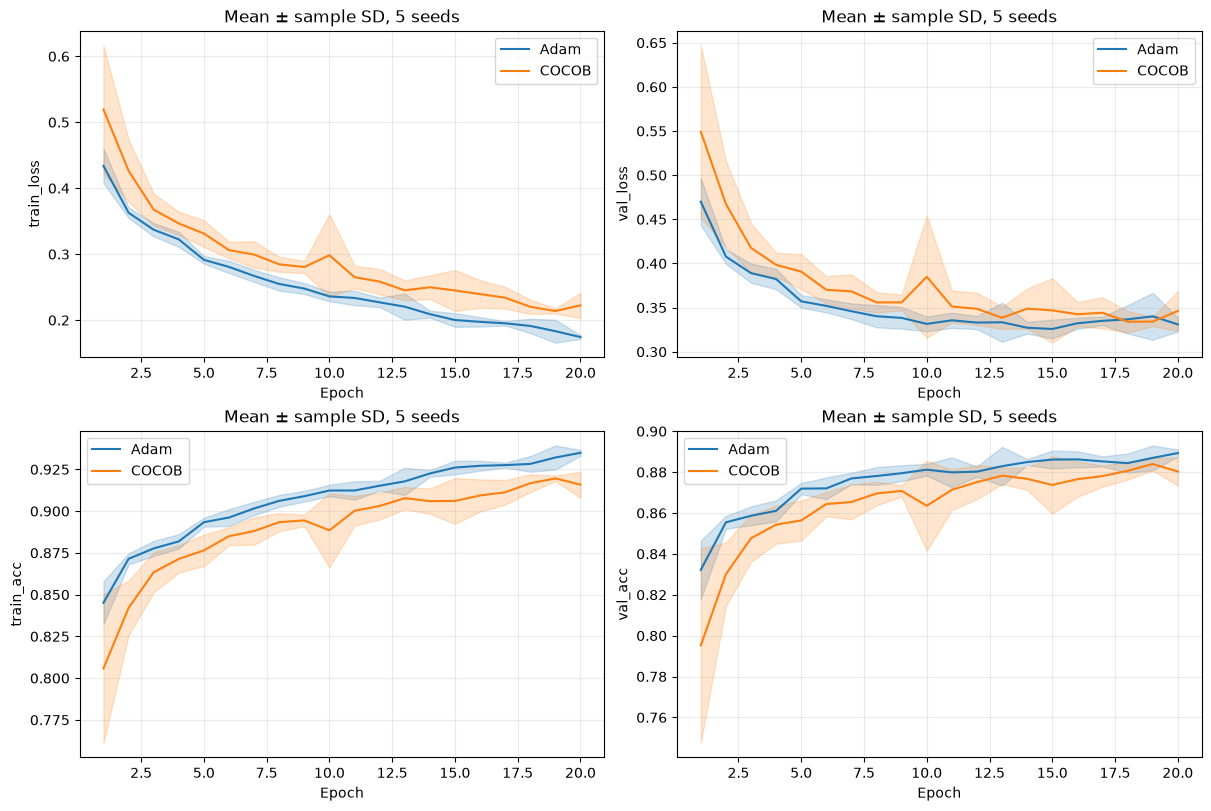

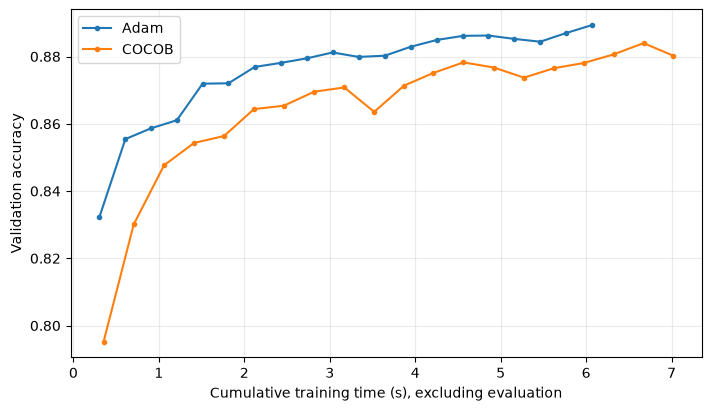

Final epoch: mean ± sample SD (5 seeds)
Adam lr = 0.001
  train_loss: 0.17434 ± 0.00284
  train_acc: 0.93495 ± 0.00171
  val_loss: 0.33096 ± 0.00780
  val_acc: 0.88932 ± 0.00175
  train_seconds: 6.06482 ± 0.07908
COCOB lr = None
  train_loss: 0.22230 ± 0.01898
  train_acc: 0.91586 ± 0.00782
  val_loss: 0.34626 ± 0.02249
  val_acc: 0.88028 ± 0.00683
  train_seconds: 7.01601 ± 0.05513
Paired accuracy differences COCOB − Adam (percentage points): [-0.71 -2.02 -0.11 -0.33 -1.35]
Mean paired difference: -0.904 percentage points


In [50]:
def cocob_values(method, metric):
    return np.array([[r[metric] for r in cocob_history
                      if r['method'] == method and r['seed'] == seed]
                     for seed in cocob_seeds])

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
for ax, metric in zip(axes.ravel(), ['train_loss', 'val_loss', 'train_acc', 'val_acc']):
    for method in ['Adam', 'COCOB']:
        data = cocob_values(method, metric)
        mean, sd = data.mean(0), data.std(0, ddof=1)
        x = np.arange(1, cocob_epochs+1)
        line, = ax.plot(x, mean, label=method)
        ax.fill_between(x, mean-sd, mean+sd, color=line.get_color(), alpha=0.2)
    ax.set(xlabel='Epoch', ylabel=metric, title='Mean ± sample SD, 5 seeds')
    ax.grid(alpha=0.25)
    ax.legend()
fig.savefig(cocob_dir / 'learning_curves.png', dpi=160)
plt.show()

fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
for method in ['Adam', 'COCOB']:
    ax.plot(cocob_values(method, 'train_seconds').mean(0),
            cocob_values(method, 'val_acc').mean(0), marker='.', label=method)
ax.set(xlabel='Cumulative training time (s), excluding evaluation', ylabel='Validation accuracy')
ax.legend()
ax.grid(alpha=0.25)
fig.savefig(cocob_dir / 'time_comparison.png', dpi=160)
plt.show()

print('Final epoch: mean ± sample SD (5 seeds)')
for method in ['Adam', 'COCOB']:
    print(method, 'lr =', cocob_selected[method])
    for metric in ['train_loss', 'train_acc', 'val_loss', 'val_acc', 'train_seconds']:
        samples = cocob_values(method, metric)[:, -1]
        print(f'  {metric}: {samples.mean():.5f} ± {samples.std(ddof=1):.5f}')
difference = cocob_values('COCOB', 'val_acc')[:, -1] - cocob_values('Adam', 'val_acc')[:, -1]
print('Paired accuracy differences COCOB − Adam (percentage points):', np.round(difference*100, 3))
print(f'Mean paired difference: {difference.mean()*100:.3f} percentage points')

### Результаты 4.1 и выводы

Выбран Adam lr=0.001. COCOB использовал alpha=100, eps=1e-8 без подбора. Ниже результат последней, заранее фиксированной 20-й эпохи — среднее ± выборочное отклонение по пяти сидам:

| Метод | Train accuracy | Validation accuracy | Validation loss | Время обучения, с |
|---|---:|---:|---:|---:|
| Adam | 93.50 ± 0.17% | 88.93 ± 0.18% | 0.3310 ± 0.0078 | 6.273 ± 0.079 |
| COCOB | 91.59 ± 0.78% | 88.03 ± 0.68% | 0.3463 ± 0.0225 | 7.511 ± 0.451 |

COCOB успешно обучает эту архитектуру без заданного learning rate и достигает близкого к Adam качества. Однако Adam оказался лучше на всех пяти сидах: средняя разница COCOB−Adam равна −0.904 п.п. У COCOB заметнее колебания кривых и разброс между запусками. Более высокий лосс на тренировочной выборке также показывает, что в этом бюджете он менее эффективно минимизировал обучающую функцию. Его преимущество в эксперименте — отсутствие поиска lr.

### 4.2 Реализация современной функции активации (2 + 2 балла).
Реализуйте одну из активаций, предложенных на лекции или в статье. Например, `Hardswish`. Сравните сеть с вашей активацией и с `ReLU`.

**Дополнительные баллы** вы получите, если функция будет уникальна среди сдавших задание.

### Bent Identity

Используем f(x) = x + (sqrt(1+x²)−1)/2 и производную f′(x) = 1 + x/(2 sqrt(1+x²)). Формула встречается, например, в [исследовании Manchester, раздел 2.3.2.1](https://research.manchester.ac.uk/files/139690215/FULL_TEXT.PDF) при коэффициенте масштаба 1. Функция гладкая, f(0)=0, f′(0)=1; производная лежит в (0.5, 1.5), поэтому отрицательные входы не выключаются, как у ReLU. Это не гарантирует лучшую точность или отсутствие проблем с градиентами в глубокой сети.

Сравниваем ReLU и Bent Identity в сети 784–128–128–10, заменяя только две скрытые активации. Для обеих используем COCOB (alpha=100, eps=1e-8) из раздела 4.1, нормировку x/255, batch=256, 20 эпох и 5 seed. Начальные веса и порядок батчей попарно одинаковые. Сохраняем He-инициализацию скрытых слоёв и Xavier выходного слоя из предыдущего опыта: это контролируемая замена активации, а не отдельный поиск оптимальных условий для каждой функции. He изначально ориентирована на ReLU; вывод ограничен этой конфигурацией. Гиперпараметры не подбираем по результатам сравнения.


Bent Identity: gradcheck, gradgradcheck, reference autograd and large-input checks passed.


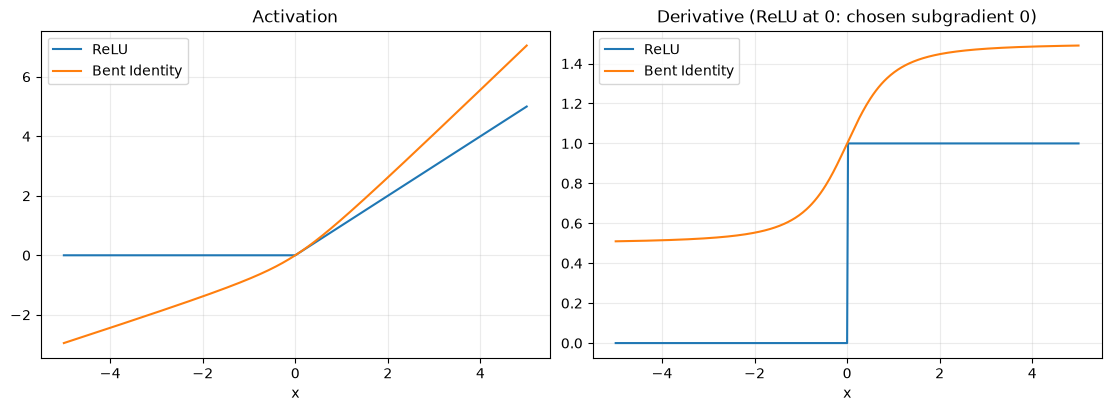

In [51]:
class BentIdentityFunction(Function):
    @staticmethod
    def forward(ctx, x):
        ctx.save_for_backward(x)
        radius = torch.hypot(x, torch.ones_like(x))
        return x + 0.5 * x * (x / (radius + 1))

    @staticmethod
    def backward(ctx, grad_output):
        (x,) = ctx.saved_tensors
        radius = torch.hypot(x, torch.ones_like(x))
        return grad_output * (1 + 0.5 * (x / radius))

class BentIdentity(nn.Module):
    def forward(self, x):
        return BentIdentityFunction.apply(x)

x_check = torch.tensor([-10., -1., -0.01, 0., 0.01, 1., 10.],
                       dtype=torch.float64, requires_grad=True)
assert gradcheck(BentIdentityFunction.apply, (x_check,))
assert torch.autograd.gradgradcheck(BentIdentityFunction.apply, (x_check,))
reference = x_check + (torch.sqrt(1 + x_check.square()) - 1)/2
torch.testing.assert_close(BentIdentity()(x_check), reference)
upstream = torch.linspace(-2, 2, x_check.numel(), dtype=x_check.dtype)
manual = torch.autograd.grad(BentIdentity()(x_check), x_check, upstream)[0]
automatic = torch.autograd.grad(reference, x_check, upstream)[0]
torch.testing.assert_close(manual, automatic)
large = torch.tensor([-1e20, 0., 1e20], requires_grad=True)
output = BentIdentity()(large)
output.sum().backward()
assert torch.isfinite(output).all() and torch.isfinite(large.grad).all()
assert large.grad[1].item() == 1.
print('Bent Identity: gradcheck, gradgradcheck, reference autograd and large-input checks passed.')

import json
import time
from pathlib import Path
bent_dir = Path('bent_identity_experiment')
bent_dir.mkdir(exist_ok=True)
grid = torch.linspace(-5, 5, 501, dtype=torch.float64, requires_grad=True)
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
for name, activation in [('ReLU', ReLU()), ('Bent Identity', BentIdentity())]:
    output = activation(grid)
    derivative = torch.autograd.grad(output.sum(), grid)[0]
    axes[0].plot(grid.detach(), output.detach(), label=name)
    axes[1].plot(grid.detach(), derivative, label=name)
for ax, title in zip(axes, ['Activation', 'Derivative (ReLU at 0: chosen subgradient 0)']):
    ax.set(xlabel='x', title=title)
    ax.grid(alpha=0.25)
    ax.legend()
fig.savefig(bent_dir / 'activation_and_derivative.png', dpi=160)
plt.show()


In [52]:
import json
import time
from pathlib import Path

bent_dir = Path('bent_identity_experiment')
bent_dir.mkdir(exist_ok=True)
torch.set_num_threads(4)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True
bent_batch_size, bent_epochs = 256, 20
bent_seeds = [11, 22, 33, 44, 55]
bent_train_eval = DataLoader(train_dataset, batch_size=bent_batch_size, shuffle=False)
bent_val_eval = DataLoader(test_dataset, batch_size=bent_batch_size, shuffle=False)

def bent_model(seed, activation):
    torch.manual_seed(seed)
    np.random.seed(seed)
    net = Network(hidden_layers_size=128, num_layers=3)
    linear = [m for m in net.modules() if isinstance(m, Linear)]
    for layer in linear[:-1]:
        nn.init.kaiming_normal_(layer.weight, nonlinearity='relu')
        nn.init.zeros_(layer.bias)
    nn.init.xavier_normal_(linear[-1].weight)
    nn.init.zeros_(linear[-1].bias)
    if activation == 'Bent Identity':
        for index, layer in enumerate(net.layers):
            if isinstance(layer, ReLU):
                net.layers[index] = BentIdentity()
    return net.to(device=device, dtype=torch.float32)

class ActivationNetwork(nn.Module):
    def __init__(self, seed, activation):
        super().__init__()
        self.net = bent_model(seed, activation)

    def forward(self, x):
        return self.net(x / 255.)

def synchronize():
    if device.type == 'cuda':
        torch.cuda.synchronize()
    elif device.type == 'mps':
        torch.mps.synchronize()

def bent_run(method, seed, epochs):
    net = ActivationNetwork(seed, method)
    loader = DataLoader(train_dataset, batch_size=bent_batch_size, shuffle=True,
                        generator=torch.Generator().manual_seed(seed))
    opt = COCOB(net.parameters())
    rows, elapsed = [], 0.
    for epoch in range(1, epochs+1):
        synchronize()
        start = time.perf_counter()
        perform_epoch(net, loader, CrossEntropy(), optimizer=opt, device=device)
        synchronize()
        elapsed += time.perf_counter()-start
        tl, ta = perform_epoch(net, bent_train_eval, CrossEntropy(), device=device)
        vl, va = perform_epoch(net, bent_val_eval, CrossEntropy(), device=device)
        if not np.isfinite([tl, ta, vl, va]).all():
            raise RuntimeError(f'Non-finite metrics: {method}, seed={seed}')
        row = dict(method=method, seed=seed, epoch=epoch,
                   train_loss=tl, train_acc=ta, val_loss=vl, val_acc=va,
                   train_seconds=elapsed)
        rows.append(row)
    print(f'{method}, seed={seed}: val_acc={va:.4f}, val_loss={vl:.4f}', flush=True)
    return rows

relu_initial = ActivationNetwork(11, 'ReLU')
bent_initial = ActivationNetwork(11, 'Bent Identity')
assert list(relu_initial.state_dict()) == list(bent_initial.state_dict())
for key in relu_initial.state_dict():
    torch.testing.assert_close(relu_initial.state_dict()[key],
                               bent_initial.state_dict()[key], rtol=0, atol=0)
del relu_initial, bent_initial

bent_history = []
for seed in bent_seeds:
    for method in ['ReLU', 'Bent Identity']:
        bent_history.extend(bent_run(method, seed, bent_epochs))
        (bent_dir / 'results.json').write_text(json.dumps(dict(
            config=dict(epochs=bent_epochs, seeds=bent_seeds, batch_size=bent_batch_size,
                        architecture=[784, 128, 128, 10], normalization='x/255',
                        optimizer=dict(name='COCOB', alpha=100., eps=1e-8),
                        device=str(device), torch_version=torch.__version__),
            history=bent_history), indent=2), encoding='utf-8')


ReLU, seed=11: val_acc=0.8819, val_loss=0.3272
Bent Identity, seed=11: val_acc=0.8722, val_loss=0.3569
ReLU, seed=22: val_acc=0.8695, val_loss=0.3799
Bent Identity, seed=22: val_acc=0.8680, val_loss=0.3703
ReLU, seed=33: val_acc=0.8857, val_loss=0.3369
Bent Identity, seed=33: val_acc=0.8705, val_loss=0.3615
ReLU, seed=44: val_acc=0.8861, val_loss=0.3291
Bent Identity, seed=44: val_acc=0.8725, val_loss=0.3603
ReLU, seed=55: val_acc=0.8782, val_loss=0.3582
Bent Identity, seed=55: val_acc=0.8726, val_loss=0.3538


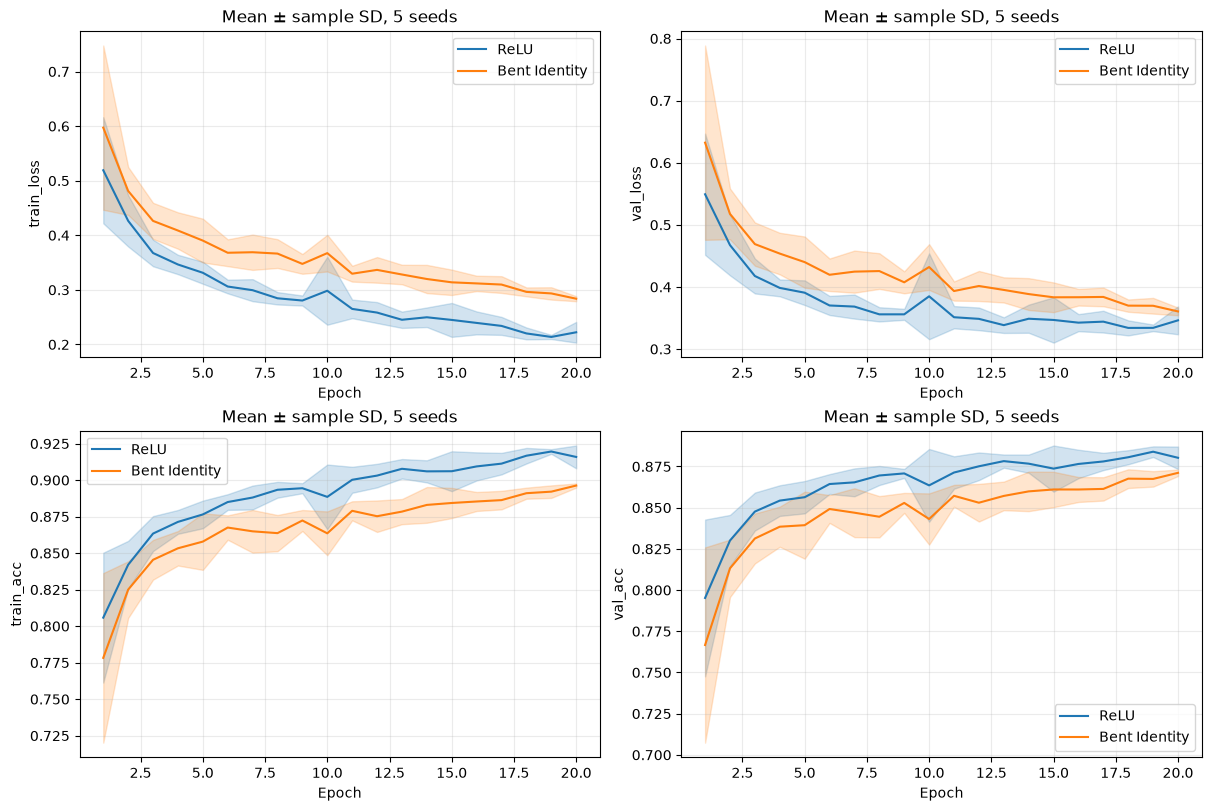

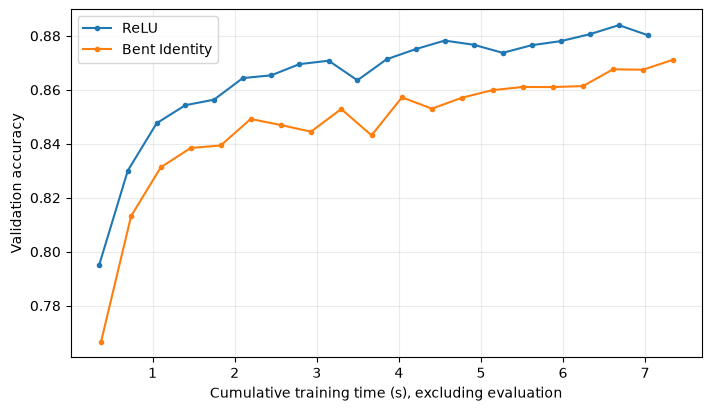

Final epoch: mean ± sample SD (5 seeds)
ReLU
  train_loss: 0.22230 ± 0.01898
  train_acc: 0.91586 ± 0.00782
  val_loss: 0.34626 ± 0.02249
  val_acc: 0.88028 ± 0.00683
  train_seconds: 7.03148 ± 0.02197
Bent Identity
  train_loss: 0.28381 ± 0.00462
  train_acc: 0.89628 ± 0.00142
  val_loss: 0.36057 ± 0.00621
  val_acc: 0.87116 ± 0.00196
  train_seconds: 7.33924 ± 0.06133
Paired accuracy differences Bent Identity − ReLU (percentage points): [-0.97 -0.15 -1.52 -1.36 -0.56]
Mean paired difference: -0.912 percentage points


In [53]:
def bent_values(method, metric):
    return np.array([[r[metric] for r in bent_history
                      if r['method'] == method and r['seed'] == seed]
                     for seed in bent_seeds])

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
for ax, metric in zip(axes.ravel(), ['train_loss', 'val_loss', 'train_acc', 'val_acc']):
    for method in ['ReLU', 'Bent Identity']:
        data = bent_values(method, metric)
        mean, sd = data.mean(0), data.std(0, ddof=1)
        x = np.arange(1, bent_epochs+1)
        line, = ax.plot(x, mean, label=method)
        ax.fill_between(x, mean-sd, mean+sd, color=line.get_color(), alpha=0.2)
    ax.set(xlabel='Epoch', ylabel=metric, title='Mean ± sample SD, 5 seeds')
    ax.grid(alpha=0.25)
    ax.legend()
fig.savefig(bent_dir / 'learning_curves.png', dpi=160)
plt.show()

fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
for method in ['ReLU', 'Bent Identity']:
    ax.plot(bent_values(method, 'train_seconds').mean(0),
            bent_values(method, 'val_acc').mean(0), marker='.', label=method)
ax.set(xlabel='Cumulative training time (s), excluding evaluation', ylabel='Validation accuracy')
ax.legend()
ax.grid(alpha=0.25)
fig.savefig(bent_dir / 'time_comparison.png', dpi=160)
plt.show()

print('Final epoch: mean ± sample SD (5 seeds)')
for method in ['ReLU', 'Bent Identity']:
    print(method)
    for metric in ['train_loss', 'train_acc', 'val_loss', 'val_acc', 'train_seconds']:
        samples = bent_values(method, metric)[:, -1]
        print(f'  {metric}: {samples.mean():.5f} ± {samples.std(ddof=1):.5f}')
difference = bent_values('Bent Identity', 'val_acc')[:, -1] - bent_values('ReLU', 'val_acc')[:, -1]
print('Paired accuracy differences Bent Identity − ReLU (percentage points):', np.round(difference*100, 3))
print(f'Mean paired difference: {difference.mean()*100:.3f} percentage points')

### Выводы по заданию 4.2

Bent Identity реализована собственными Function и Module. Проверены первая и вторая производные (CPU, float64), совпадение с обычным autograd, точка ноль и большие конечные аргументы. Добавлены графики активаций, производных, обучения и качества в зависимости от времени.

После 20 эпох с COCOB, среднее ± выборочное SD по пяти сидам:

| Активация | Train accuracy | Validation accuracy | Validation loss | Время обучения, с |
|---|---:|---:|---:|---:|
| ReLU | 91.59 ± 0.78% | 88.03 ± 0.68% | 0.3463 ± 0.0225 | 7.758 ± 0.097 |
| Bent Identity | 89.63 ± 0.14% | 87.12 ± 0.20% | 0.3606 ± 0.0062 | 8.046 ± 0.128 |

Bent Identity успешно обучается, но уступила ReLU на всех пяти сидах; средняя парная разница составляет −0.912 п.п. Её конечные метрики имеют меньший разброс, однако и точность на обучающей выборке ниже: гладкость и ненулевая производная на отрицательной полуоси не обеспечили преимущества по оптимизации. Разрыв точности между тренировкой и валидацией составляет около 2.51 п.п. против 3.56 п.п. у ReLU, но меньший разрыв сам по себе не означает лучшую модель — итоговая точность на валидации также ниже.

Обучение с Bent Identity заняло примерно на 3.7% больше времени на RTX 3060. Вывод относится к общей He/Xavier-инициализации, COCOB и 20 эпохам; отдельная настройка инициализации или оптимизатора для Bent Identity не проводилась. Из положительной производной отдельного слоя не следует отсутствие затухания или роста градиентов во всей сети.